# 07 · Forecasting & Scenarios

The v0.4 milestone projects metrics forward and measures distance to policy targets:

1. **Baseline trend forecasts** with approximate prediction intervals.
2. **Scenario comparison** under constant annual-rate assumptions.
3. **Policy target gap analysis** against a trend projection.

> These are transparent baseline projections that assume the recent linear trend continues. They are screening tools, **not** calibrated climate or policy forecasts.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)


def find_repo_root(start: Path | None = None) -> Path:
    """Walk upwards until the directory containing pyproject.toml is found."""
    here = (start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    return here


REPO_ROOT = find_repo_root()
RAW_DIR = REPO_ROOT / "data" / "raw"
DB_PATH = REPO_ROOT / "data" / "processed" / "carbon_transition.duckdb"
MARTS_DIR = REPO_ROOT / "data" / "processed" / "marts"
print(f"Repository root: {REPO_ROOT}")


Repository root: C:\Users\diogo\work_code\portfolio\carbon-transition-duckdb-lab


In [2]:
from carbon_transition_duckdb.config import ProjectPaths
from carbon_transition_duckdb.pipeline import build_duckdb_lakehouse, load_transition_mart
from carbon_transition_duckdb.risk.scoring import filter_entities
from carbon_transition_duckdb.sample_data import generate_synthetic_owid_data

if not DB_PATH.exists():
    generate_synthetic_owid_data(RAW_DIR, start_year=2010, end_year=2024)
    build_duckdb_lakehouse(
        ProjectPaths(raw_dir=RAW_DIR, database=DB_PATH, export_dir=MARTS_DIR)
    )

mart = filter_entities(load_transition_mart(DB_PATH))
last_year = int(mart["year"].max())
print(f"Mart: {mart.shape[0]} rows, last year {last_year}")


Mart: 75 rows, last year 2024


## 1. Baseline trend forecasts

Each country's CO2 series is fit by ordinary least squares and extrapolated, with an approximate 95% prediction interval.

In [3]:
from carbon_transition_duckdb.forecasting import trend_table

trend_table(mart, 'co2')

,country,annual_change,r_squared,n_obs
0,Atlantis,-0.6899,0.739,15
1,Borealia,-0.4229,0.135,15
2,Cyrenia,-0.6509,0.971,15
3,Deltora,0.5469,0.083,15
4,Estavia,-1.0927,0.964,15


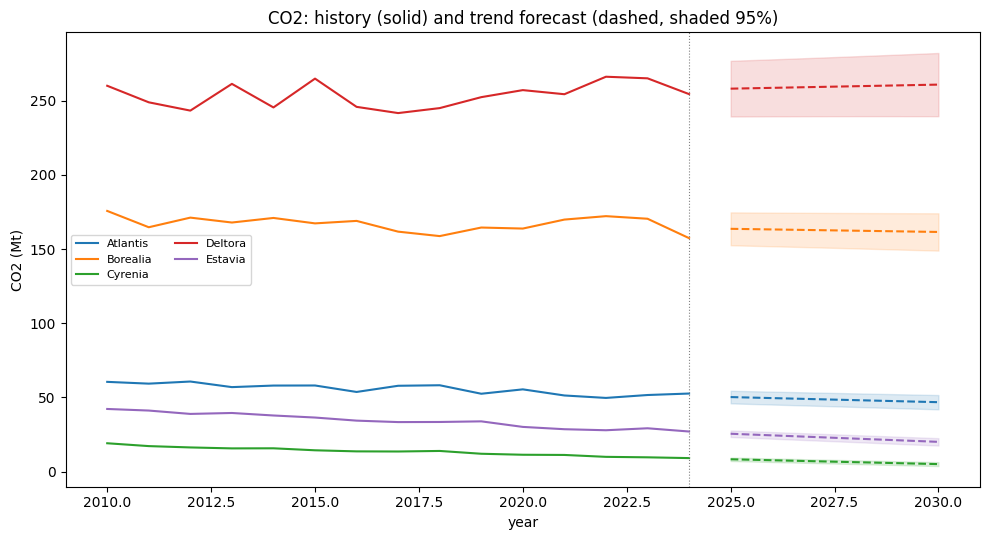

In [4]:
from carbon_transition_duckdb.forecasting import forecast_metric

fig, ax = plt.subplots(figsize=(10, 5.5))
colors = plt.cm.tab10.colors
for i, country in enumerate(sorted(mart['country'].unique())):
    hist = mart[mart['country'] == country].sort_values('year')
    color = colors[i % len(colors)]
    ax.plot(hist['year'], hist['co2'], color=color, label=country)
    fc = forecast_metric(mart, country, 'co2', horizon=6)
    ax.plot(fc['year'], fc['forecast'], '--', color=color)
    ax.fill_between(fc['year'], fc['lower'], fc['upper'], color=color, alpha=0.15)
ax.axvline(last_year, color='grey', linewidth=0.8, linestyle=':')
ax.set_xlabel('year')
ax.set_ylabel('CO2 (Mt)')
ax.set_title('CO2: history (solid) and trend forecast (dashed, shaded 95%)')
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

## 2. Scenario comparison

Project one country forward under several constant annual-rate scenarios, anchored to its business-as-usual (historical CAGR) rate.

In [5]:
from carbon_transition_duckdb.forecasting import (
    default_scenarios,
    historical_cagr,
    scenario_comparison,
)

country = 'Borealia'
bau = historical_cagr(mart, country, 'co2')
scenarios = default_scenarios(bau)
paths = scenario_comparison(mart, country, 'co2', scenarios, horizon=10)
print(f'{country} business-as-usual rate: {bau:.2%}/yr')
paths

Borealia business-as-usual rate: -0.78%/yr


,business_as_usual,flat,reduce_2pct,reduce_5pct
year,,,,
2025,156.1421,157.3759,154.2284,149.5071
2026,154.9179,157.3759,151.1438,142.0317
2027,153.7034,157.3759,148.1209,134.9302
2028,152.4983,157.3759,145.1585,128.1837
2029,151.3027,157.3759,142.2553,121.7745
2030,150.1165,157.3759,139.4102,115.6857
2031,148.9396,157.3759,136.6220,109.9015
2032,147.7719,157.3759,133.8896,104.4064
2033,146.6134,157.3759,131.2118,99.1861


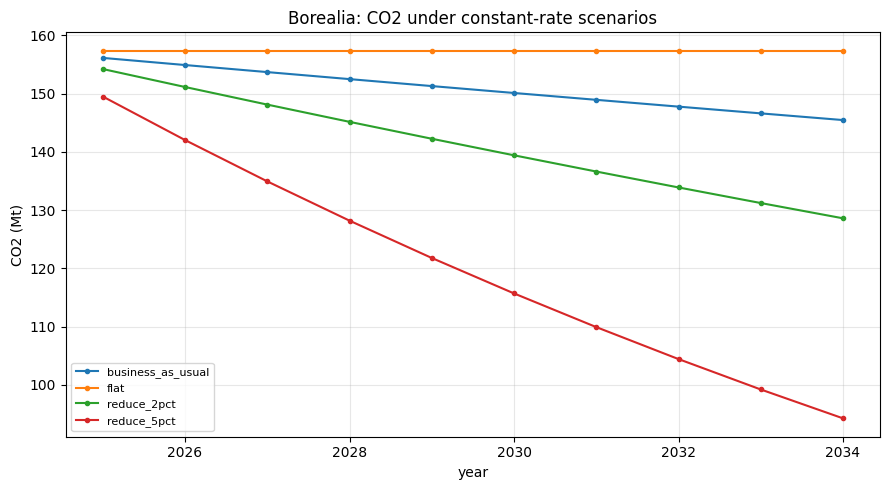

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
for column in paths.columns:
    ax.plot(paths.index, paths[column], marker='.', label=column)
ax.set_xlabel('year')
ax.set_ylabel('CO2 (Mt)')
ax.set_title(f'{country}: CO2 under constant-rate scenarios')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 3. Policy target gap analysis

Measure each country's distance to a **30% cut by 2030 vs. 2010**, using the baseline trend projection at the target year. `on_track` is True when the projection meets or beats the target.

In [7]:
from carbon_transition_duckdb.forecasting import ReductionTarget, target_gap_frame

target = ReductionTarget(metric='co2', base_year=2010, target_year=2030, reduction=0.30)
gaps = target_gap_frame(mart, target)
gaps

,country,base_value,target_value,projected_value,gap,gap_pct,on_track
0,Atlantis,60.4976,42.3483,46.7956,4.4473,10.50,False
1,Borealia,175.7187,123.0031,161.5438,38.5407,31.33,False
2,Cyrenia,19.1148,13.3804,5.0575,-8.3228,-62.20,True
3,Deltora,260.0812,182.0568,260.8678,78.8110,43.29,False
4,Estavia,42.2278,29.5595,20.0599,-9.4996,-32.14,True


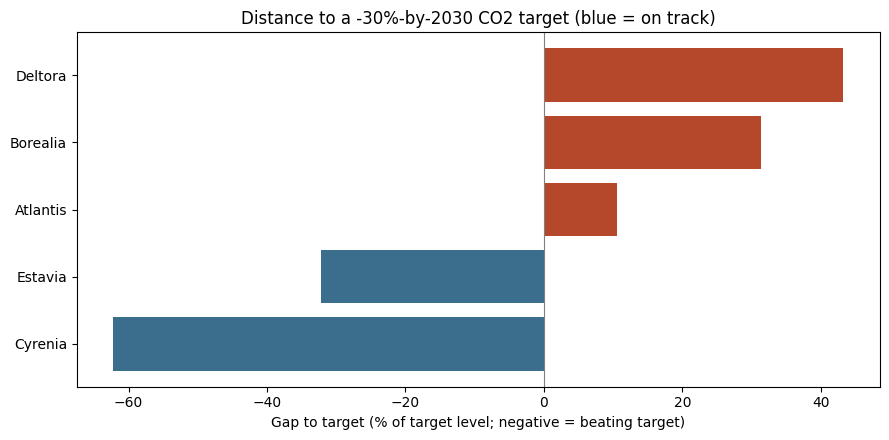

In [8]:
ordered = gaps.sort_values('gap_pct')
colors = ['#3b6e8c' if ok else '#b5482a' for ok in ordered['on_track']]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(ordered['country'], ordered['gap_pct'], color=colors)
ax.axvline(0, color='grey', linewidth=0.8)
ax.set_xlabel('Gap to target (% of target level; negative = beating target)')
ax.set_title('Distance to a -30%-by-2030 CO2 target (blue = on track)')
fig.tight_layout()
plt.show()

## Takeaways

- Baseline forecasts extrapolate the fitted trend and report honest uncertainty that widens with the projection horizon.
- Scenario tables make the BAU-versus-reduction contrast explicit without any hidden model.
- Target-gap analysis turns a stated policy goal into a concrete, per-country distance under trend continuation.
- Every projection here is a transparent assumption, not a prediction of policy outcomes -- use them to prioritise review, not to forecast the future.